# 11 - Sensor-Level Analysis

This notebook compares dissolved oxygen, dissolved oxygen percentage and water temperature across the three AquaSensor monitoring stations used by AquaPulse.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aquasensor_final.csv"
)

df = pd.read_csv(DATA_FILE, low_memory=False)

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

print(df.shape)
df.head()

(107974, 32)


,timestamp,sensor_id,sensor_name,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct,air_temperature_c,sunshine_wm2,cloud_cover_pct,hour,...,do_mgl_next_60min,do_pct_next_60min,do_mgl_next_75min,do_pct_next_75min,do_mgl_next_90min,do_pct_next_90min,do_mgl_next_105min,do_pct_next_105min,do_mgl_next_120min,do_pct_next_120min
0,2025-06-01 00:04:48,941115,Derwent 13-50,13.0,9.7,91.2,11.3,0.0,17.0,0.0,...,9.7,90.5,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9
1,2025-06-01 00:16:44,941115,Derwent 13-50,12.9,9.7,91.1,11.3,0.0,17.0,0.0,...,9.6,90.4,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8
2,2025-06-01 00:28:41,941115,Derwent 13-50,12.9,9.7,90.9,11.3,0.0,17.0,0.0,...,9.6,90.2,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7
3,2025-06-01 00:40:37,941115,Derwent 13-50,12.8,9.7,90.7,11.3,0.0,17.0,0.0,...,9.6,90.1,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6
4,2025-06-01 00:52:33,941115,Derwent 13-50,12.8,9.7,90.5,11.3,0.0,17.0,0.0,...,9.6,89.9,9.6,89.8,9.6,89.7,9.6,89.6,9.6,89.5


In [2]:
summary = (
    df.groupby("sensor_name")
    .agg(
        records=("sensor_name", "size"),
        mean_do_mgl=("dissolved_oxygen_mgl", "mean"),
        min_do_mgl=("dissolved_oxygen_mgl", "min"),
        max_do_mgl=("dissolved_oxygen_mgl", "max"),
        mean_do_pct=("dissolved_oxygen_pct", "mean"),
        mean_temperature=("temperature", "mean"),
    )
    .round(2)
)

summary

,records,mean_do_mgl,min_do_mgl,max_do_mgl,mean_do_pct,mean_temperature
sensor_name,,,,,,
Derwent 13,41460,11.36,1.3,15.8,99.21,10.04
Derwent 13-50,33690,11.49,4.1,21.8,100.27,10.00
Derwent 21,32824,11.89,9.3,14.1,100.87,8.73


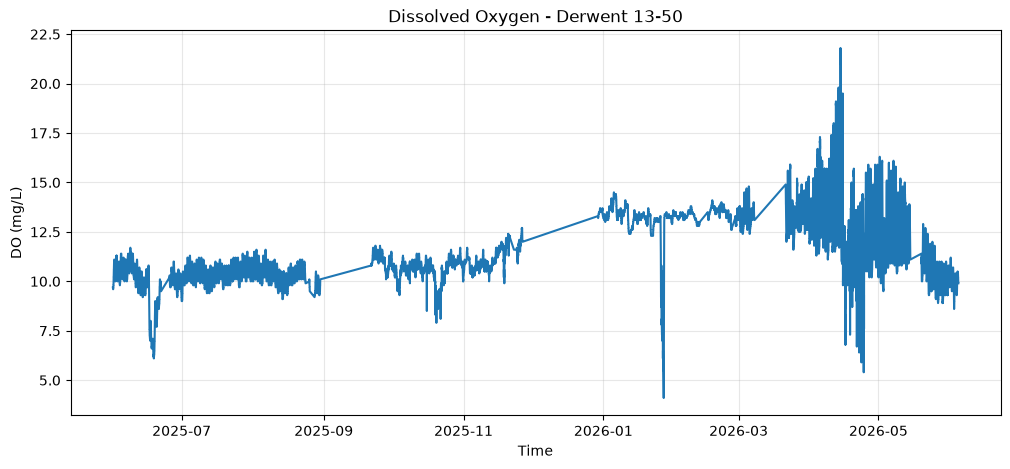

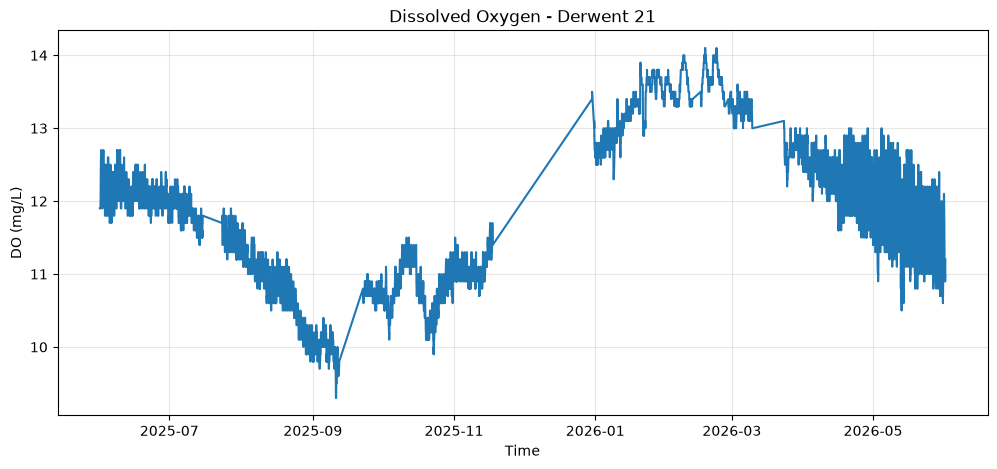

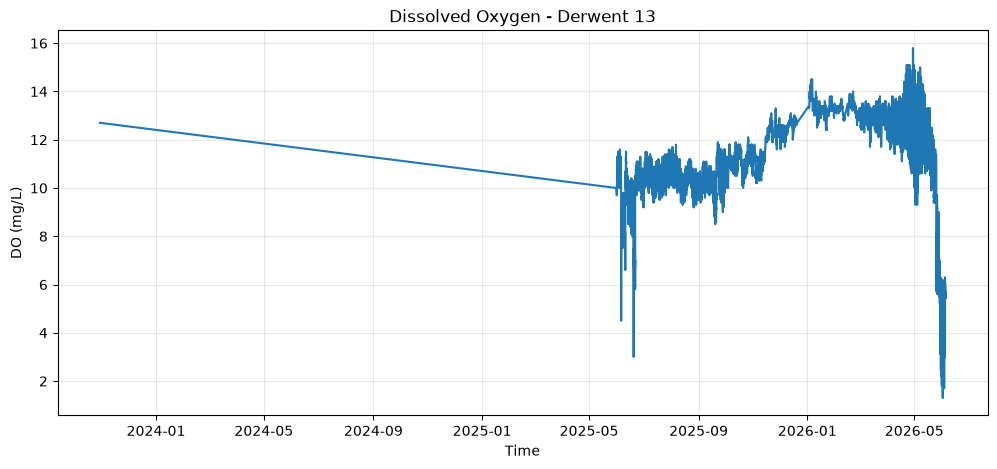

In [3]:
for station in df["sensor_name"].dropna().unique():

    station_df = df[
        df["sensor_name"] == station
    ].sort_values("timestamp")

    plt.figure(figsize=(12, 5))

    plt.plot(
        station_df["timestamp"],
        station_df["dissolved_oxygen_mgl"]
    )

    plt.title(f"Dissolved Oxygen - {station}")
    plt.xlabel("Time")
    plt.ylabel("DO (mg/L)")
    plt.grid(alpha=0.3)
    plt.show()

## Interpretation

Sensor-level analysis was necessary because environmental and model behaviour may differ between monitoring locations. Comparing the three stations helps determine whether River Derwent conditions remain consistent throughout the monitored section or whether local differences are present.